### PROJECT NAME: "Relationship Between Security Priorities and Social Development"

### PROJECT CONTEXT:
Today, the European Union suffers from the revealed unpreparedness for self-defence. In today's geopolitical situation, it is becoming increasingly difficult for European governments to balance social spending with military spending.  The former have been particularly popular since the beginning of the 21st century and have underpinned the development of many EU economies, far behind the latter. This project aims to analyse the relationship between military spending and social development indicators across countries using data from the Stockholm International Peace Research Institute SIPRI Military Expenditure Database and the World Bank API. Note, in order for the data to be more complete, the analysis starts from 2010.
### RESEARCH QUESTION: To what extent is military expenditure associated with levels of economic development?
### USAGE OF THIS JUPITER NOTEBOOK: 
1. Install required libraries
2. Place the SIPRI Excel file in the project folder
3. Run notebook from top to bottom
4. Raw and cleaned data will be automatically exported
5. Offline CSV files are included for reproducibility



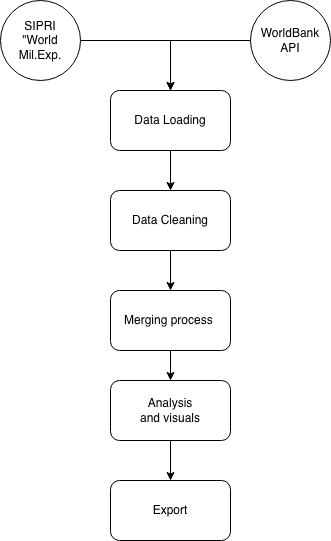

In [13]:
#PROJECT PIPELINE
from IPython.display import Image, display

display(Image("/Users/romanklymenko/Downloads/PIPELINE.drawio.png"))

,Country,Year,Military_Spending
11969,Algeria,2010,3.189982
11971,Morocco,2010,3.390796
11972,Tunisia,2010,1.236171
11974,Angola,2010,4.177585
11976,Botswana,2010,2.759080


,Country,Year,Military_Spending,country,year,gdp_per_capita,health_spending,education_spending,gov_consumption
0,Algeria,2010,3.189982,Algeria,2010.0,4912.785855,4.640014,8.691771,16.963306
1,Morocco,2010,3.390796,NaN,NaN,NaN,NaN,NaN,NaN
2,Tunisia,2010,1.236171,Tunisia,2010.0,4291.861209,5.609508,5.963070,15.153645
3,Angola,2010,4.177585,Angola,2010.0,4101.637156,2.363739,3.421320,18.052816
4,Botswana,2010,2.759080,NaN,NaN,NaN,NaN,NaN,NaN


                    Military_Spending  gdp_per_capita  health_spending  \
Military_Spending            1.000000       -0.067160        -0.045694   
gdp_per_capita              -0.067160        1.000000         0.471315   
health_spending             -0.045694        0.471315         1.000000   
education_spending           0.086212        0.271141         0.487310   
gov_consumption              0.221547        0.352970         0.588921   

                    education_spending  gov_consumption  
Military_Spending             0.086212         0.221547  
gdp_per_capita                0.271141         0.352970  
health_spending               0.487310         0.588921  
education_spending            1.000000         0.683194  
gov_consumption               0.683194         1.000000  


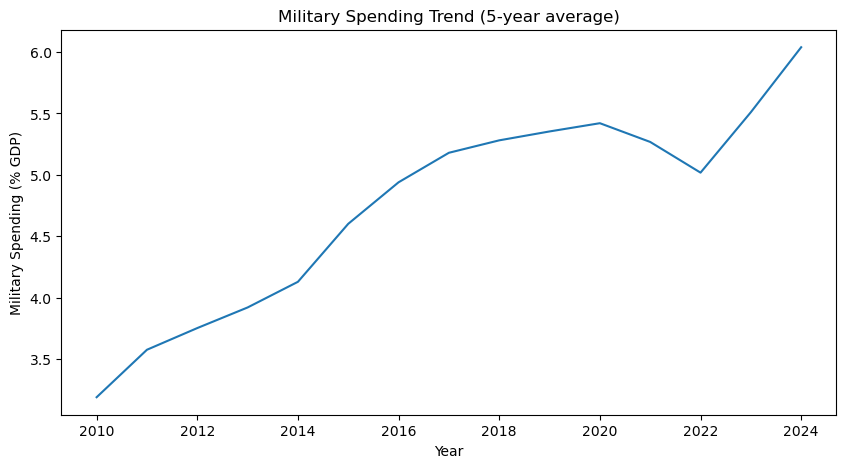

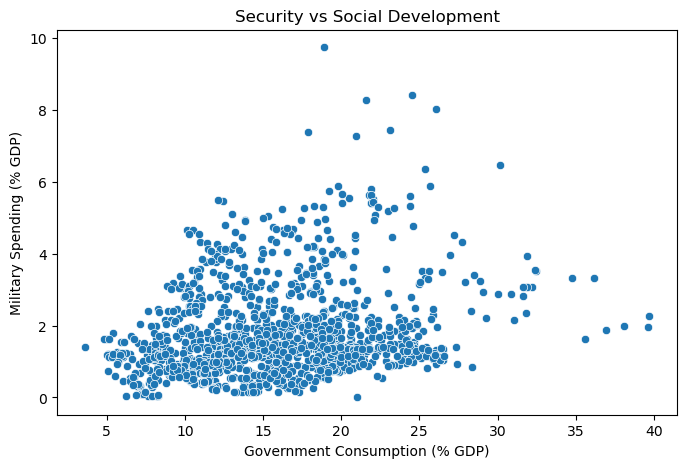

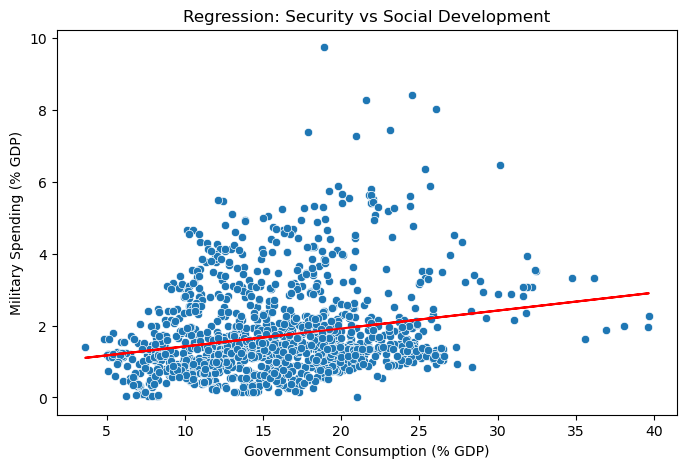

In [4]:
# import of libraries

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from IPython.display import display
# data extraction (SIPRI dataset)
df = pd.read_excel(
    "/Users/romanklymenko/Downloads/SIPRI-Milex-data-1949-2024_2.xlsx",
    sheet_name="Share of GDP",
    header=5
)

#  data transformation , wide to long format 

df_long = df.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Military_Spending"
)


#  data cleaning

df_long["Year"] = pd.to_numeric(
    df_long["Year"],
    errors="coerce"
)

df_long["Military_Spending"] = pd.to_numeric(
    df_long["Military_Spending"],
    errors="coerce"
)

df_long = df_long.dropna()

df_long["Year"] = df_long["Year"].astype(int)
# Setting parameter to check only  after year 2000
df_long = df_long[df_long["Year"] >= 2010]


# convert values into percentages

df_long["Military_Spending"] = (
    df_long["Military_Spending"] * 100
)


# export raw dataset 

df_long.to_csv(
    "raw_sipri.csv",
    index=False
)

# display key information

display(df_long.head())


# API connection (World Bank API)

def fetch_indicator(indicator, name):

    url = (
        f"https://api.worldbank.org/v2/country/all/"
        f"indicator/{indicator}?format=json&per_page=20000"
    )

    data = requests.get(url).json()

    out = []

    for item in data[1]:

        out.append({

            "country": item["country"]["value"],

            "year": item["date"],

            name: item["value"]

        })

    df = pd.DataFrame(out)

    df = df.dropna()

    df["year"] = df["year"].astype(int)

    return df


#  collecting social development indicators

gdp = fetch_indicator(
    "NY.GDP.PCAP.CD",
    "gdp_per_capita"
)

health = fetch_indicator(
    "SH.XPD.CHEX.GD.ZS",
    "health_spending"
)

edu = fetch_indicator(
    "SE.XPD.TOTL.GD.ZS",
    "education_spending"
)

gov = fetch_indicator(
    "NE.CON.GOVT.ZS",
    "gov_consumption"
)


#  merging World Bank datasets

social = (
    gdp.merge(
        health,
        on=["country", "year"],
        how="inner"
    )
    .merge(
        edu,
        on=["country", "year"],
        how="inner"
    )
    .merge(
        gov,
        on=["country", "year"],
        how="inner"
    )
)

merged = merged[merged["Year"] >= 2010]

#  integration of SIPRI + World Bank datasets

merged = pd.merge(

    df_long,

    social,

    left_on=["Country", "Year"],

    right_on=["country", "year"],

    how="left"
)


#  export processed dataset

merged.to_csv(
    "results.csv",
    index=False
)

# print key information

display(merged.head())


# correlation matrix

correlation_matrix = merged[[
    "Military_Spending",
    "gdp_per_capita",
    "health_spending",
    "education_spending",
    "gov_consumption"
]].corr()

print(correlation_matrix)


#  visualization 1 (time-series analysis)

country = "Algeria"

tmp = merged[
    merged["Country"] == country
].sort_values("Year")


# rolling average smooths volatility

tmp["Military_Spending_Smooth"] = (
    tmp["Military_Spending"]
    .rolling(5, min_periods=1)
    .mean()
)


plt.figure(figsize=(10,5))

plt.plot(
    tmp["Year"],
    tmp["Military_Spending_Smooth"]
)

plt.title(
    "Military Spending Trend (5-year average)"
)

plt.xlabel("Year")

plt.ylabel("Military Spending (% GDP)")

plt.show()


#  visualization 2 (relationship analysis)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged,
    x="gov_consumption",
    y="Military_Spending"
)

plt.title(
    "Security vs Social Development"
)

plt.xlabel(
    "Government Consumption (% GDP)"
)

plt.ylabel(
    "Military Spending (% GDP)"
)

plt.show()


# machine learning analysis

df_reg = merged.dropna(
    subset=[
        "Military_Spending",
        "gov_consumption"
    ]
).copy()


X = df_reg[[
    "gov_consumption"
]]

y = df_reg[
    "Military_Spending"
]


# linear regression model

model = LinearRegression()

model.fit(X, y)


# predicted values

df_reg["pred"] = model.predict(X)


# regression visualization

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_reg,
    x="gov_consumption",
    y="Military_Spending"
)

plt.plot(
    df_reg["gov_consumption"],
    df_reg["pred"],
    color="red"
)

plt.title(
    "Regression: Security vs Social Development"
)

plt.xlabel(
    "Government Consumption (% GDP)"
)

plt.ylabel(
    "Military Spending (% GDP)"
)

plt.show()

### CONCLUSION AND FINDINGS ###
The results showed that there is no strong direct relationship between military spending and indicators such as GDP per capita, spending on education, and health. An increase in defence spending does not necessarily mean a decline in social development.
At the same time, there was a noticeably weak positive connection between military expenditures and government funds, which could indicate the existence of economically powerful powers that would simultaneously support both the security sector and the social sphere. Overall, the results demonstrate that the balance between security and social development lies not only in the level of military expenditures, but also in the overall economic and institutional capacity of the state.

### USAGE OF AI
AI was used to help with formulating an RQ regarding a topic of interest and interested. More precisely, AI was used to help with ideas on how to integrate two interested for me databases (SIPRI and WorldBank API). Additionally, AI was used to understand how to create a line that does the datasets merging process (security + social). AI was used to help retrieve needed data from the World Bank API, specifficaly was asked how to retrieve health, education GDP per capita categories.